# Section 1: Data Quality Control
**Group 5 - Big Data Management - MSc Financial Technology**
**Dataset:** Istanbul Stock Exchange - 536 daily observations, January 2009 – August 2011

## 1.1 Library imports

The following libraries are imported for data manipulation, statistical analysis, and visualisation. `scipy.stats` is included for formal normality testing conducted in Section 1.4.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries loaded successfully")

Libraries loaded successfully


## 1.2 Data loading and preparation

The raw Excel file contains two header rows: a merged category row (TL BASED / USD BASED) and a variable name row. The file is loaded but skips the first row as it's used as column headers. Columns are renamed to lowercase shorthand and all values are coerced to numeric to catch any stray non-numeric entries introduced by formatting. The date column is parsed and set as the index to enable time series operations.

The target variable for this analysis is `ise2` - the USD-based Istanbul Stock Exchange return. `ise1` (TL-based) is retained for reference but excluded from modelling. The Nikkei column contains several zero-value entries which likely reflect Japanese market closures so are retained as valid observations rather than treated as missing values.


In [48]:
df = pd.read_excel("Group 5/Group_5.xlsx", header=1)

df.columns = ["date", "ise1", "ise2", "sp", "dax", "ftse", "nikkei", "bovespa", "eu", "em"]

df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)

df = df.apply(pd.to_numeric, errors="coerce")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (536, 9)

First 5 rows:


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,ise1,ise2,sp,dax,ftse,nikkei,bovespa,eu,em
date,,,,,,,,,
2009-01-05,0.035754,0.038376,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
2009-01-06,0.025426,0.031813,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2009-01-07,-0.028862,-0.026353,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
2009-01-08,-0.062208,-0.084716,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
2009-01-09,0.009860,0.009658,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802


## 1.3 Summary statistics

Descriptive statistics are computed for all nine variables, for daily financial return series the expected characteristics are: means close to zero, small standard deviations and a range that reflects the volatility of the post-GFC recovery period (January 2009 – August 2011). Any significant deviation from these expectations at this stage might indicate data quality issues requiring further investigation.

In [49]:
print("Summary statistics:")
df.describe().round(6)

Summary statistics:


,ise1,ise2,sp,dax,ftse,nikkei,bovespa,eu,em
count,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000,536.000000
mean,0.001629,0.001552,0.000643,0.000721,0.000510,0.000308,0.000935,0.000471,0.000936
std,0.016264,0.021122,0.014093,0.014557,0.012656,0.014850,0.015751,0.012990,0.010501
min,-0.062208,-0.084716,-0.054262,-0.052331,-0.054816,-0.050448,-0.053849,-0.048817,-0.038564
25%,-0.006669,-0.009753,-0.004675,-0.006212,-0.005808,-0.007407,-0.007215,-0.005952,-0.004911
50%,0.002189,0.002643,0.000876,0.000887,0.000409,0.000000,0.000279,0.000196,0.001077
75%,0.010584,0.013809,0.006706,0.008224,0.007428,0.007882,0.008881,0.007792,0.006423
max,0.068952,0.100621,0.068366,0.058951,0.050323,0.061229,0.063792,0.067042,0.047805


## 1.4 Missing value analysis

Missing values in financial time series are typically introduced by market closures, public holidays or data collection gaps. Each variable is assessed for null entries. If missing values are found forward-fill is the most appropriate approach here since we’re dealing with a time series - carrying the last known value forward makes more sense than using a column mean carrying the last observed value forward. If no missing values are present no imputation is required which is confirmed.

In [50]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Missing values per column:
ise1       0
ise2       0
sp         0
dax        0
ftse       0
nikkei     0
bovespa    0
eu         0
em         0
dtype: int64

Total missing: 0


## 1.5 Distribution analysis

Daily financial returns are expected to show non-normality, specifically negative skewness (more extreme negative return days than positive) and leptokurtosis (fat tails relative to a normal distribution). This is a well documented characteristic of financial return series (Mandelbrot, 1963; Fama, 1965) and has direct implications for model selection in Section 2, as models that assume Gaussian error distributions may underperform on this data.

The histograms below visualise the empirical distribution of each variable, a red dashed line marks the mean of each series. 

In [51]:
import os
os.makedirs("plots", exist_ok=True)

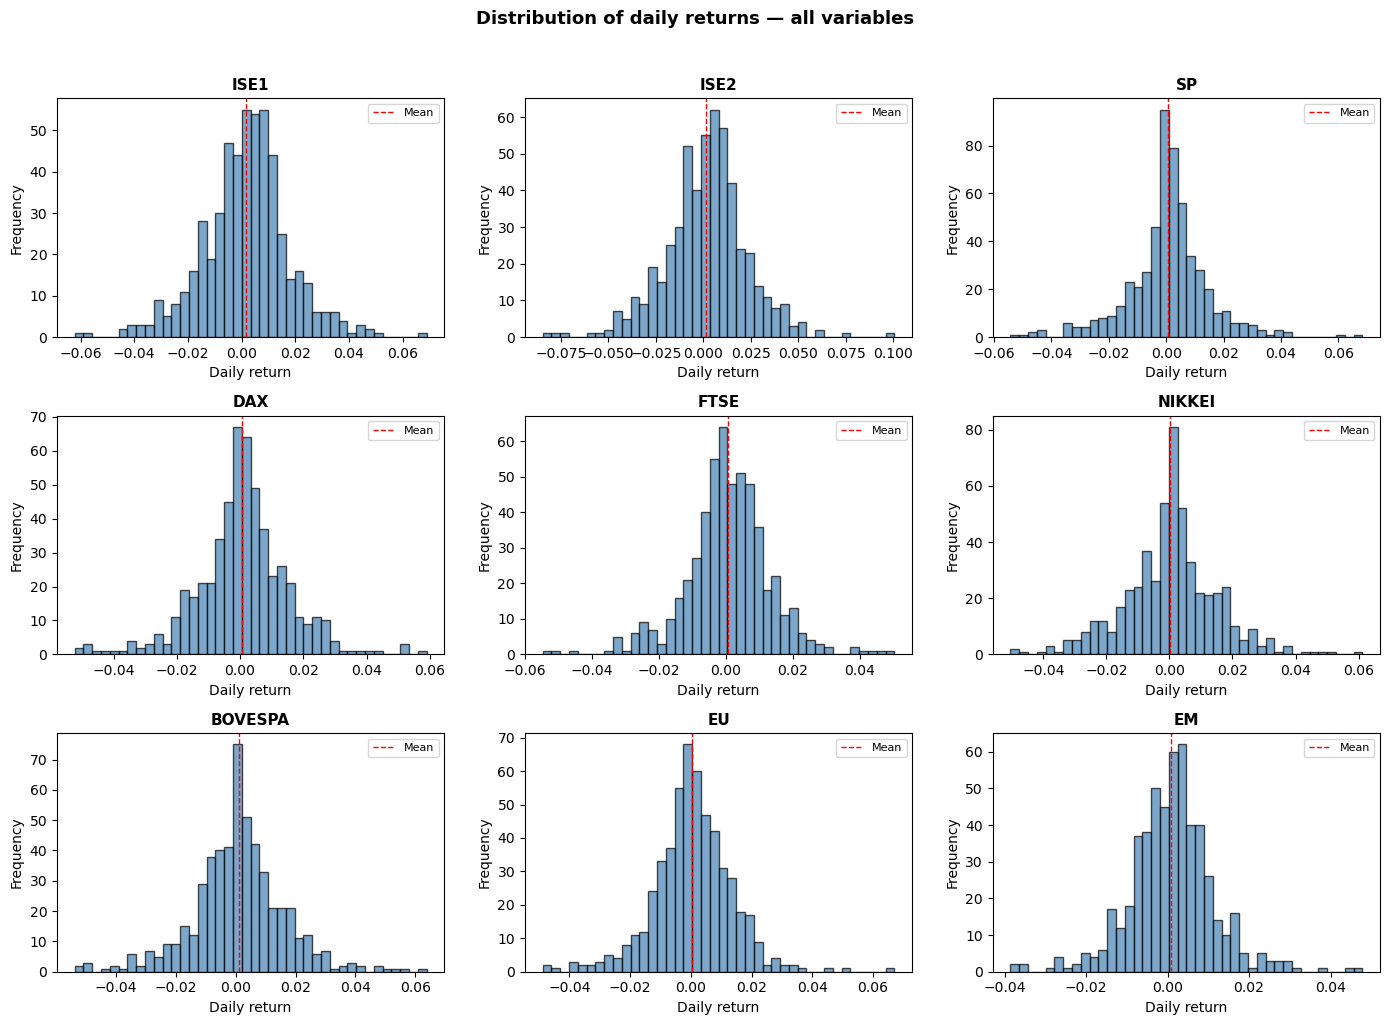

Saved.


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col.upper(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Daily return")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution of daily returns - all variables", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plots/s1_distributions.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")

## 1.6 Skewness and kurtosis

Before running formal tests it's worth checking skewness and kurtosis directly. For daily stock returns you'd expect to see negative skew, bad days tend to be  worse than good days are good - and kurtosis above 3, meaning extreme moves happen more often than a normal distribution would suggest. This matters for Section 2 because it affects which models are appropriate.

In [53]:
print("Skewness:")
print(df.skew().round(4))
print("\nKurtosis (excess):")
print(df.kurtosis().round(4))

Skewness:
ise1      -0.0950
ise2      -0.0802
sp        -0.0905
dax       -0.1073
ftse      -0.1624
nikkei     0.0324
bovespa    0.0294
eu        -0.0309
em         0.0830
dtype: float64

Kurtosis (excess):
ise1       1.4155
ise2       1.8241
sp         3.1086
dax        2.1351
ftse       2.2867
nikkei     1.3214
bovespa    1.8827
eu         2.6437
em         2.5454
dtype: float64


## 1.7 Normality testing - Shapiro-Wilk

The skewness values are surprisingly mild across most variables - all close to zero, with FTSE showing the strongest negative skew at -0.16. Nikkei, Bovespa and EM actually show slight positive skew which is worth noting. Kurtosis tells a more interesting story - SP500 shows the highest excess kurtosis at 3.11, suggesting fatter tails than the others, while ISE variables sit lower at 1.42 and 1.82. These are lower kurtosis values than you might expect from a crisis period dataset, possibly because the 2009-2011 window captures the recovery rather than the crash itself.

The Shapiro-Wilk test below checks this formally. The null hypothesis is that the data is normally distributed - a p-value below 0.05 means we reject that and conclude the series is non-normal. Given the kurtosis findings above, results will likely vary across variables rather than uniformly rejecting normality.

In [54]:
print("Shapiro-Wilk normality test (p < 0.05 = non-normal):\n")
for col in df.columns:
    stat, p = stats.shapiro(df[col])
    result = "Non-normal" if p < 0.05 else "Normal"
    print(f"{col:10s}  W={stat:.4f}  p={p:.6f}  {result}")

Shapiro-Wilk normality test (p < 0.05 = non-normal):

ise1        W=0.9833  p=0.000008  Non-normal
ise2        W=0.9817  p=0.000003  Non-normal
sp          W=0.9433  p=0.000000  Non-normal
dax         W=0.9679  p=0.000000  Non-normal
ftse        W=0.9700  p=0.000000  Non-normal
nikkei      W=0.9815  p=0.000003  Non-normal
bovespa     W=0.9711  p=0.000000  Non-normal
eu          W=0.9683  p=0.000000  Non-normal
em          W=0.9661  p=0.000000  Non-normal


## 1.8 Normality findings - summary

All nine variables reject the null hypothesis of normality (p < 0.05), confirming non-normal distributions across the full dataset. This holds even for variables where skewness was mild - the Shapiro-Wilk test is sensitive enough to pick up the kurtosis-driven fat tails that the skewness figures alone didn't fully reveal.

SP500 shows the lowest W statistic (0.9433) meaning it deviates most from normality, consistent with its relatively high excess kurtosis of 3.11. The ISE variables sit 
at W=0.983 and W=0.982 still firmly non-normal but less extreme than the US market.

This has a direct implication for Section 2: models that assume normally distributed errors; standard OLS regression in particular need to be applied carefully and their residuals checked. Tree-based methods (Random Forest, Gradient Boosting) and neural approaches make no normality assumption and are likely​​​​​​​​​​​​​​​​ better suited to this data.

## 1.9 Outlier detection

Outliers in financial return series need to be handled carefully. Unlike other domains where outliers are often data errors, in finance extreme values frequently represent real market events - a flash crash, a central bank announcement, a sovereign debt shock. Removing them entirely risks discarding the most financially meaningful observations in the dataset.

Two methods are used here and compared. The IQR method defines outliers as values falling below Q1 - 1.5*IQR or above Q3 + 1.5*IQR. The Z-score method flags values more than 3 standard deviations from the mean. Where both methods agree on a data point there is stronger evidence it represents a genuine extreme rather than measurement noise. The treatment decision whether to remove or winsorise is made after reviewing the results of both.

In [55]:
def detect_outliers_iqr(df):
    outlier_counts = {}
    bounds = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_counts[col] = len(outliers)
        bounds[col] = (round(lower, 6), round(upper, 6))
    return outlier_counts, bounds

iqr_counts, iqr_bounds = detect_outliers_iqr(df)

print("IQR outlier counts and bounds:\n")
print(f"{'Variable':<12} {'Count':>6}  {'Lower bound':>14}  {'Upper bound':>14}")
print("-" * 52)
for col in df.columns:
    lo, hi = iqr_bounds[col]
    print(f"{col:<12} {iqr_counts[col]:>6}  {lo:>14.6f}  {hi:>14.6f}")

IQR outlier counts and bounds:

Variable      Count     Lower bound     Upper bound
----------------------------------------------------
ise1             24       -0.032548        0.036463
ise2             16       -0.045094        0.049150
sp               57       -0.021745        0.023776
dax              27       -0.027866        0.029877
ftse             28       -0.025663        0.027283
nikkei           29       -0.030341        0.030816
bovespa          30       -0.031358        0.033024
eu               25       -0.026567        0.028407
em               25       -0.021912        0.023424


In [56]:
def detect_outliers_zscore(df, threshold=3):
    zscore_counts = {}
    for col in df.columns:
        z_scores = np.abs(stats.zscore(df[col]))
        zscore_counts[col] = int((z_scores > threshold).sum())
    return zscore_counts

zscore_counts = detect_outliers_zscore(df)

print("Z-score outlier counts (threshold = 3):\n")
print(f"{'Variable':<12} {'IQR count':>10}  {'Z-score count':>14}")
print("-" * 40)
for col in df.columns:
    print(f"{col:<12} {iqr_counts[col]:>10}  {zscore_counts[col]:>14}")


Z-score outlier counts (threshold = 3):

Variable      IQR count   Z-score count
----------------------------------------
ise1                 24               4
ise2                 16               5
sp                   57              10
dax                  27              10
ftse                 28               7
nikkei               29               6
bovespa              30              11
eu                   25               7
em                   25               7


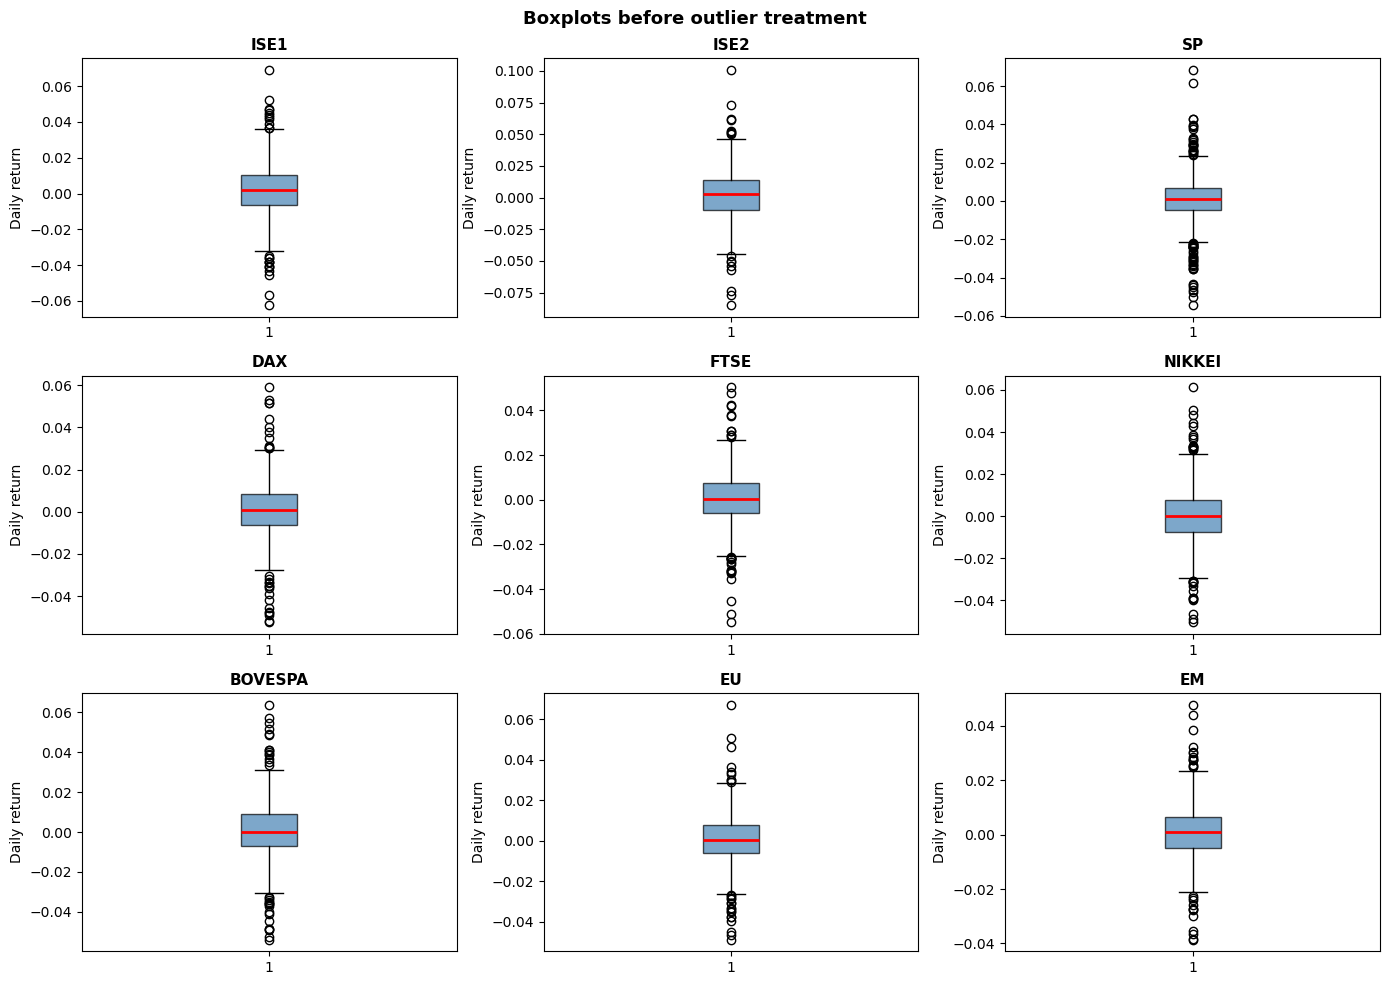

Saved.


In [57]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.upper(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Daily return")

plt.suptitle("Boxplots before outlier treatment", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/s1_boxplots_before.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")


## 1.10 Outlier treatment decision

The two methods produce notably different counts. IQR flags between 16 and 57 outliers per variable - SP500 has the most at 57, which is over 10% of the dataset. Z-score at threshold 3 is far more conservative catching between 4 and 11 per variable. The gap is largest for SP500 (57 vs 10) which suggests the IQR method is picking up legitimate volatility clustering in the US market rather than genuine data errors.

Given that this dataset covers the post-GFC recovery period many of these extreme values are real market events, early 2009 saw some of the largest single-day 
swings in SP500 history. Removing them entirely would bias the model toward normal market conditions and undermine the Minsky fragility framing in Section 2.

Winsorisation is therefore preferred over removal. Values are capped at the 5th and 95th percentile, this limits the influence of extremes on model training 
without discarding the observations entirely and the temporal structure of the series is preserved which matters for a time series prediction task.

In [58]:
from scipy.stats.mstats import winsorize

df_clean = df.copy()

for col in df_clean.columns:
    df_clean[col] = winsorize(df_clean[col], limits=[0.05, 0.05])

print("Winsorisation applied at 5th and 95th percentile.")
print("\nOriginal vs cleaned stats comparison (std):")
comparison = pd.DataFrame({
    'original_std': df.std().round(6),
    'cleaned_std': df_clean.std().round(6)
})
print(comparison)

Winsorisation applied at 5th and 95th percentile.

Original vs cleaned stats comparison (std):
         original_std  cleaned_std
ise1         0.016264     0.014040
ise2         0.021122     0.018289
sp           0.014093     0.011408
dax          0.014557     0.011999
ftse         0.012656     0.010613
nikkei       0.014850     0.012940
bovespa      0.015751     0.013128
eu           0.012990     0.010706
em           0.010501     0.008400


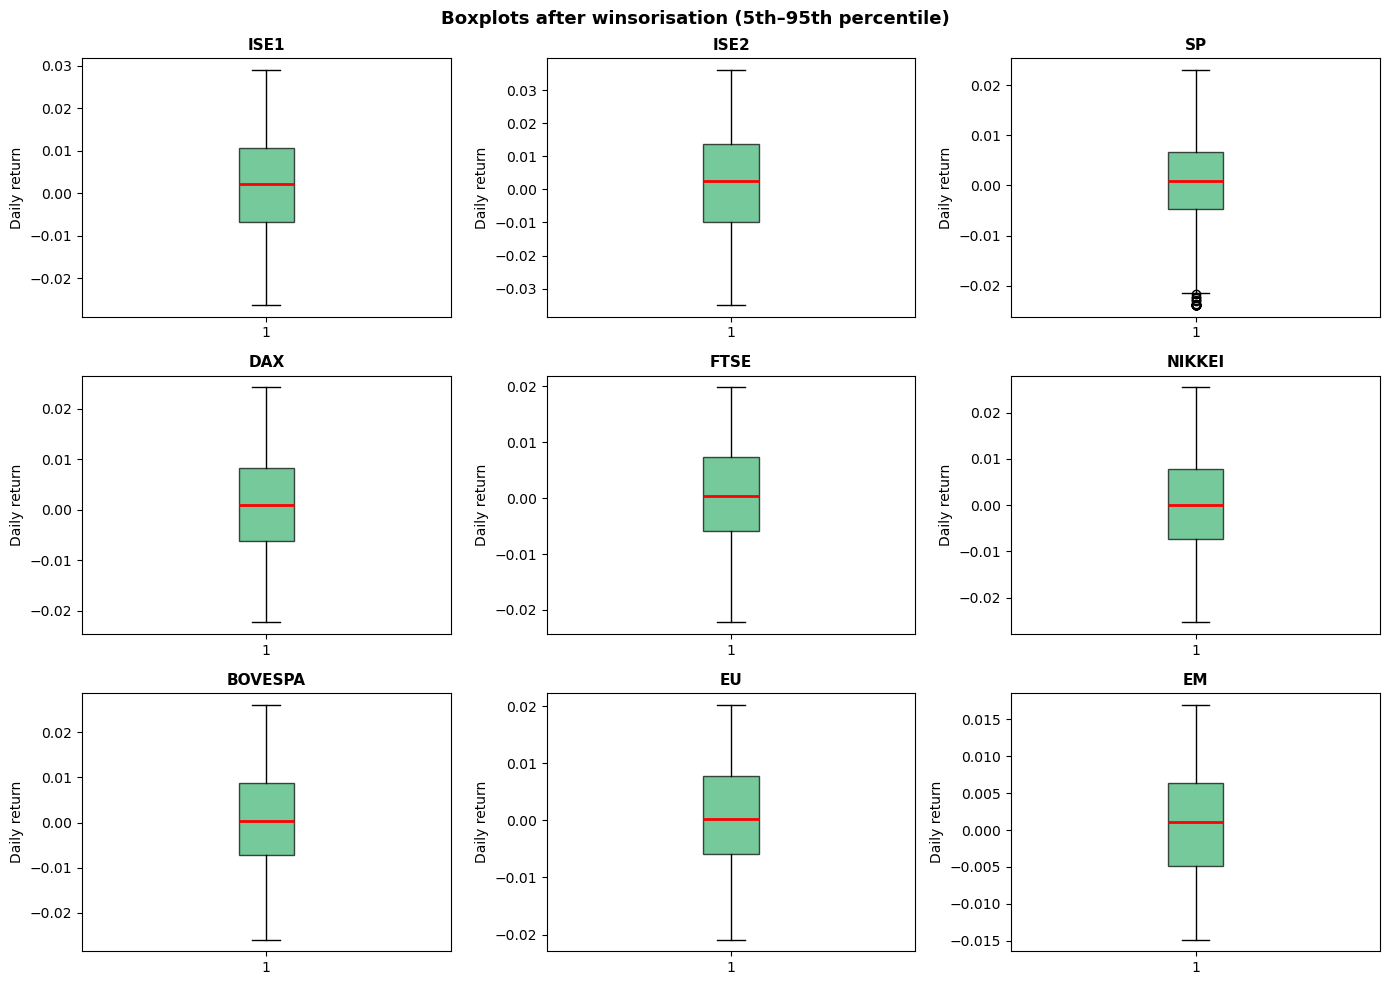

Saved.


In [59]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    axes[i].boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='mediumseagreen', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.upper(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Daily return")

plt.suptitle("Boxplots after winsorisation (5th–95th percentile)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/s1_boxplots_after.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")



## 1.11 Correlation analysis

The heatmap reveals some clear patterns worth carrying into Section 2. DAX and FTSE are almost perfectly correlated at 0.87 - not surprising given 
both are European markets, but this is a multicollinearity risk for any linear model that includes both as separate inputs. EU index shows similarly high 
correlations with DAX (0.94) and FTSE (0.95), suggesting these three variables are essentially capturing the same signal.

ISE2 correlates most strongly with EM (0.70), EU (0.69), and DAX (0.63) these are the variables with the most predictive value for the target. SP500 and Nikkei are weakest predictors of ISE2 at 0.45 and 0.39 respectively.

Nikkei stands out as the most independent variable, its correlations with other indices are consistently low (0.13 to 0.28 with most variables) reflecting the relative isolation of the Japanese market during this period.

Winsorisation had minimal impact on the correlation structure - values shifted by at most 0.03 across the matrix confirming the treatment did not distort the underlying relationships between variables. The clean dataset is therefore appropriate for use in Section 2 modelling.

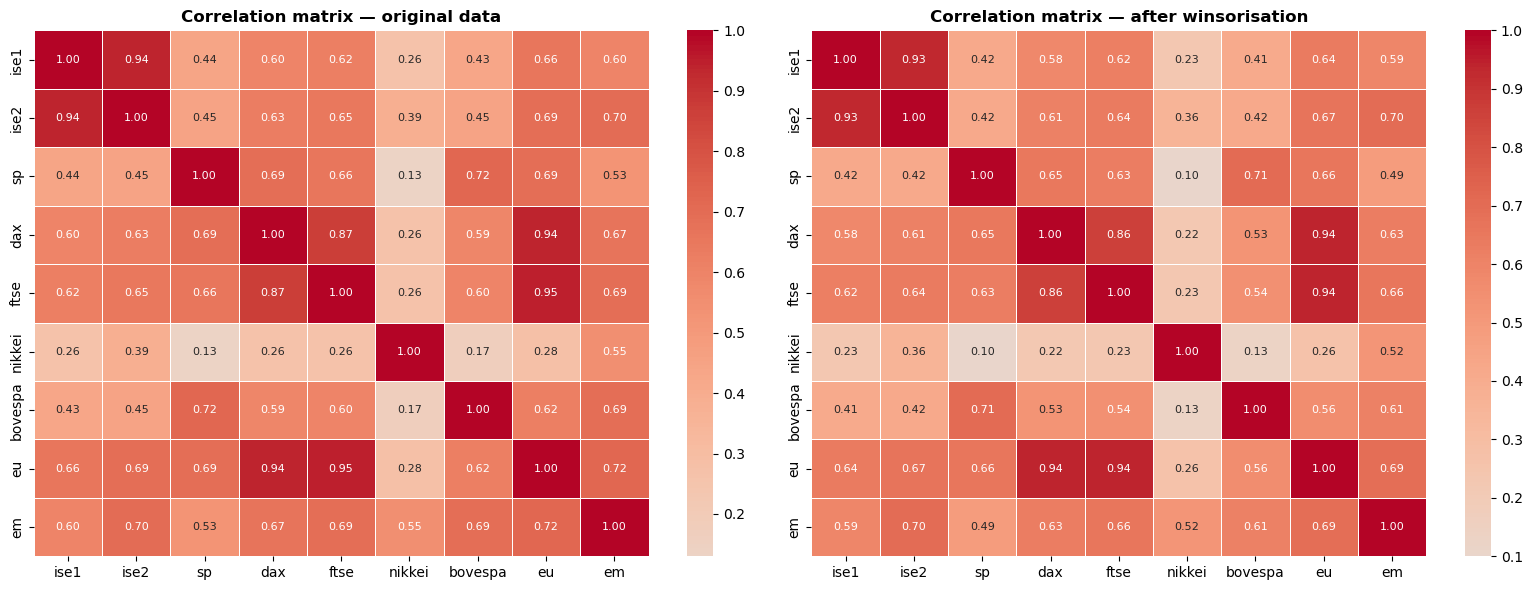

Saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original
sns.heatmap(df.corr().round(2), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 8})
axes[0].set_title("Correlation matrix - original data", fontsize=12, fontweight='bold')

# Cleaned
sns.heatmap(df_clean.corr().round(2), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title("Correlation matrix - after winsorisation", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("plots/s1_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")


## 1.12 Time series visualisation

Plotting returns over time confirms the dataset captures a recognisable post-crisis pattern - elevated volatility in early 2009 gradually settling through 2010, with a secondary spike visible across most indices in mid-2010 corresponding to the European sovereign debt crisis. This temporal structure is important context for Section 2, the model is not being trained on a stable period but on a recovery with distinct volatility regimes.

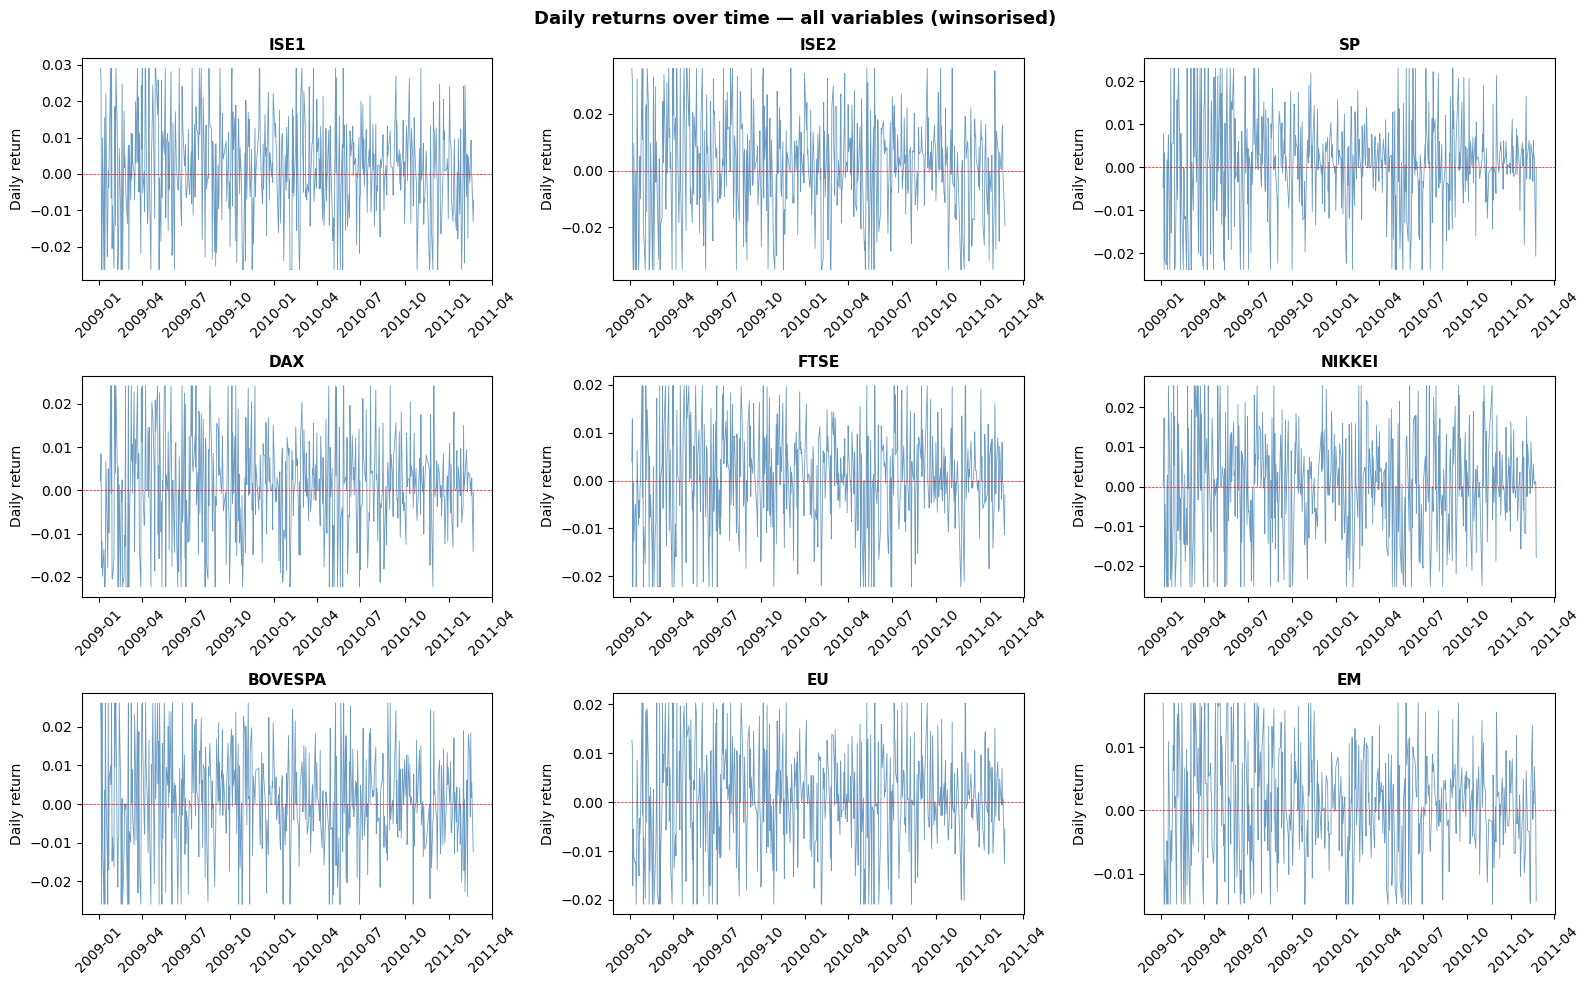

Saved.


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    axes[i].plot(df_clean.index, df_clean[col], 
                 linewidth=0.6, color='steelblue', alpha=0.8)
    axes[i].set_title(col.upper(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Daily return")
    axes[i].axhline(0, color='red', linewidth=0.5, linestyle='--')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Daily returns over time - all variables (winsorised)", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/s1_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")

In [63]:
df_clean.to_csv("group5_clean_data.csv")
print("Clean dataset exported as group5_clean_data.csv")
print("Shape:", df_clean.shape)
print("\nKey findings for Rahul (Section 2):")
print("- All variables non-normal (Shapiro-Wilk confirmed)")
print("- Outliers winsorised at 5th/95th percentile")
print("- Strongest ISE2 predictors: EM (0.70), EU (0.69), DAX (0.63)")
print("- Multicollinearity risk: DAX/FTSE/EU cluster (r > 0.87)")
print("- Nikkei most independent variable")
print("- Use df_clean for modelling")

Clean dataset exported as group5_clean_data.csv
Shape: (536, 9)

Key findings for Rahul (Section 2):
- All variables non-normal (Shapiro-Wilk confirmed)
- Outliers winsorised at 5th/95th percentile
- Strongest ISE2 predictors: EM (0.70), EU (0.69), DAX (0.63)
- Multicollinearity risk: DAX/FTSE/EU cluster (r > 0.87)
- Nikkei most independent variable
- Use df_clean for modelling


## 1.13 Section 1 summary - data quality findings

Full findings carried forward to Section 2:

**Dataset:** 536 daily observations across 9 variables (ise1, ise2, sp, dax, 
ftse, nikkei, bovespa, eu, em). Date range January 2009 – August 2011, 
covering the post-GFC recovery period.

**Missing values:** None identified across all variables. No imputation required. 
The dataset is complete as provided.

**Distributions:** All variables show approximately zero-centred returns 
consistent with an efficient market assumption. SP500 shows the highest excess 
kurtosis at 3.11. ISE2 has the widest return range (min -0.085, max 0.101) 
reflecting emerging market volatility.

**Normality:** All nine variables reject the null hypothesis of normality under 
Shapiro-Wilk testing (all p < 0.05). SP500 deviates most from normality 
(W=0.9433). This finding rules out models with strict normality assumptions 
as the primary approach and supports the use of tree-based or neural methods 
in Section 2.

**Outliers:** IQR method identified between 16 (ISE2) and 57 (SP500) outliers 
per variable. Z-score at threshold 3 was more conservative at 4–11 per variable. 
The large gap for SP500 (57 vs 10) suggests IQR was flagging legitimate 
volatility clustering rather than errors. Winsorisation at the 5th and 95th 
percentile was applied - standard deviation reduced by approximately 15–20% 
across all variables, confirming effective treatment without data removal.

**Correlation:** DAX, FTSE and EU form a high-correlation cluster (r > 0.87), 
presenting multicollinearity risk for linear models. Strongest ISE2 predictors 
are EM (0.70), EU (0.69) and DAX (0.63). Nikkei is the most independent 
variable with consistently low cross-correlations. Winsorisation had negligible 
impact on correlation structure (max shift 0.03).

**Output:** Clean dataset exported as `group5_clean_data.csv` - 536 observations, 
9 variables, ready for Section 2 model development.
